# Introdução

* Começaremos essa aula entendendo o funcionamento de uma Regressão Linear;
* Analisaremos dois métodos para otimização dos parâmetros da regressão linear: equação normal e gradiente descendente;
    * Veremos algumas variações do gradiente descendente, normalmente utilizadas em redes neurais;
* Veremos ainda a regressão polinomial e métodos de regularização;
* Finalmente, estudaremos dois modelos que são comumente usados para classificação:
    * Regressão Logística;
    * Softmax Regression;

# Regressão Linear

* Na aula 'End to End project' usamos um modelo de regressão para estimar a qualidade de vida (qv), onde $qv = θ_0 + θ_1 × rendaPerCapita.$
* Esse modelo é uma função linear que usa como feature a *rendaPerCapita*;
* $θ_0$ e $θ_1$ são os parâmetros do modelos;
* Esse modelo linear basicamente realiza a estimativa computando a soma ponderada dos amostras mais uma constante ($θ_0$) que chamamos de *bias term* (ou termo de interseção), conforme segue:

<font size=3.4>
$\hat{y} = θ_0 + θ_1x1 + θ_2x2 + ⋯ + θ_nxn$
</font>

Onde,
<br>
* $\hat{y}$ é o valor estimado.
* $n$ é o número de features.
* $x_i$ é o iésimo valor de feature.
* $θ_j$ é o jésimo parâmetro do modelo (incluindo o *bias term* $θ_0$ e os pesos $θ1, θ2, ⋯, θn$)

Observe que a equação pode ser escrita da seguinte forma:

<font size=3.4>
$\hat{y} = h_θ(x) = θ^T·x$
</font>

Onde:

* $θ$ é o vetor com os parâmetros do modelo (incluindo o *bias term* $θ_0$ e os pesos $θ1, θ2, ⋯, θn$);
* $θ^T$ e a transposta de $θ$
* $x$ é uma instância, contendo valores $x_0 .. x_n$, onde $x_0$ sempre será 1 (em função do bias term)
* $h_θ$ é a hipótese usando os parâmetros de modelo $θ$.

<h4> Como treinar o modelo </h4>

Para treinar o modelo e encontrar um bom conjunto de parâmetros precisaremos de um **função de custo** para mensurar o desempenho do modelo.
* Usaremos a Mean Squared Error (MSE):

<font size=3.4>
$MSE(X, h_θ) = \frac{1}{m}\sum_{i=1}^{m} (θ^T·x^{(i)} − y^{(i)})^2$
</font>

Por fins de simplicidade, usaremos $MSE(θ)$ ao invés de $MSE(X, h_θ)$

## Equação Normal

Para encontrar valores $θ$ que minimizem a função de custo MSE(θ), podemos usar uma fórmula matemática que faz isso diretamente:

<font size=3.4>
$\hat{θ} = (X^T·X)^{−1}·X^T·y$
</font>

* $\hat{θ}$ é o valor que minimiza a função de custo;
* **y** é o target (variável dependente), contendo $y^{(1)} .. y^{(m)}$
    * sendo $m$ o número de instâncias de treino
    
Para um maior entendimento sobre a equação normal, acesse o seguinte [link](http://cs229.stanford.edu/notes-spring2019/cs229-notes1.pdf).

* Abaixo iremos gerar alguns dados que possuem relação linear a fim de testar essa equação:

In [1]:
import numpy as np

X = 2* np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100,1) #relação linear com algum ruído gaussiano

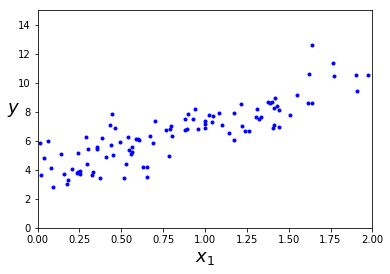

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show();

* Agora vamos calcular $\hat{θ}$ usando a equação normal

In [3]:
X_b = np.c_[np.ones((100, 1)), X]  # x0 = 1 para cada instância em função do bias term
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

* A função real que usamos para gerar os dados é y = 4 + 3X + ruído gaussiano.
* Note que a equação encontrou valores próximos:

In [4]:
theta_best

array([[3.76387713],
       [3.31160384]])

* Agora iremos fazer predições usando $\hat{θ}$ encontrado:

In [5]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
X_new_b

array([[1., 0.],
       [1., 2.]])

In [6]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.76387713],
       [10.38708481]])

* Agora vamos plotar as predições do modelo:

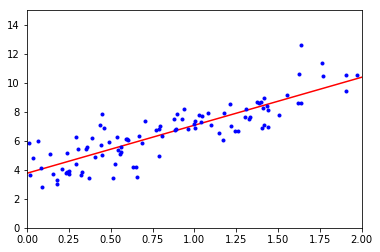

In [7]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show();

* Segue um código equivalente usando o sklearn:

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.76387713]), array([[3.31160384]]))

### Complexidade Computacional

* A equação normal computa $X^T.X$, o que gera uma matriz nxn, onde n é o número de features;
* O custo computacional de inverter tal matriz é da ordem de $\mathcal{O}(n^{2.4})$ a $\mathcal{O}(n^3)$, dependendo da implementação;
* Na prática, a equação da normal fica muito lenta quando se tem por exemplo $\sim100000$ features;
* Por outro lado, essa equação é da ordem linear $\mathcal{O}(m)$ em relação ao número de instâncias;
* Outro problema é que a matriz $X^T.X$ pode não ter uma inversa (matriz singular ou degenerada). Esse fenômeno ocorre normalmente quando:
    * Features redundantes '(linearly'dependent)'. Exemplo:
        * $x_1 = $ área em pés quadrados (feet squared);
        * $x_2 = $ área em metros quadrados;
    * Muitas features (mais features que amostras):
        * delete algumas features or use regularization;

Em seguida, veremos maneiras diferentes de treinar um modelo de Regressão Linear, levando em consideração casos mais adequados quando há um grande número de features ou instâncias de treinamento.

## Gradiente Descendente

* É um algoritmo de otimização, muito genérico, capaz de encontrar soluções ótimas para uma ampla gama de problemas.
* A ideia geral do Gradiente Descendente é ajustar os parâmetros de forma iterativa, a fim de minimizar uma função de custo.

### Ilustração:

* Suponha que você esteja perdido nas montanhas em um denso nevoeiro; 
* Você só pode sentir a inclinação do chão abaixo de seus pés. 
* Uma boa estratégia para chegar ao fundo do vale rapidamente é descer na direção da inclinação mais íngreme.
* O gradiente descendente faz exatamente isso, ele mede o gradiente local da função de erro em relação ao vetor de parâmetros θ e vai na direção do gradiente descendente.
* Quando o gradiente é zero, você atingiu um mínimo!

* Concretamente, inicia-se $θ$ com valores aleatórios, e então você melhora gradualmente, dando um passo de cada vez, cada passo tentando diminuir a função de custo (eg, o MSE), até o algoritmo convergir ao mínimo. Veja na figura abaixo:

<img src="figures/gradient1.png" />

* Existe um parâmetro do gradiente descendente chamado *learning rate* que determina o tamanho desses passos.
* Em outras palavras, o gradiente é um vetor que determino a direção do passo de descida, enquanto que o learning rate é uma constante que determina o tamanho desse passo.
* Note que com um learning rate muito baixo o algoritmo precisará de muitas iterações para convergir:

<img src="figures/gradient-small-steps.png"/>

* Já com um learning rate muito alto o algoritmo você pode pular pelo vale e acabar do outro lado (divergência):

<img src="figures/gradient-large-steps.png"/>

* Finalmente, nem todas funções de custo parecem uma bacia, 
    * Pode haver buracos, cumes, planaltos e todo tipo de terrenos irregulares, dificultando a convergência para o mínimo
* A Figura abaixo mostra os dois principais desafios dessa técnica: se a inicialização aleatória iniciar o algoritmo à esquerda, convergirá para um mínimo local, que não é tão bom quanto o mínimo global
* Se começar à direita, então vai demorar para atravessar o platô e, se você parar cedo demais, nunca atingirá o mínimo global.

<img src="figures/gradient-desafio.png"/>

* No caso do MSE para uma regressão linear, a função de custo terá um bowl shape (função convexa);
* Entretanto, se as features estiverem em escalas diferentes o modelo pode demorar bastante para covergir.
* Na figura abaixo temos a esquerda features com a mesma escala e à direita features com escalas diferentes (elongated bowl)

<img src="figures/gradient-feature-scale.png"/>

## Batch Gradiente Descendente

* Para implementar o gradiente descendente precisamos computar o gradiente da função custo em relação a cada parâmetro do modelo $θ_j$
* Em outras palavras, calcula-se o quanto a função de custo muda se mudarmos um pouquinho do $θ_j$ (derivada parcial);
* A equação abaixo mostra a derivada parcial da função de custo para o parâmetro $θ_j$:

<font size=3.4>
$\frac{∂}{∂θ_j}MSE(θ) = \frac{2}{m}\sum_{i = 1}^{m}(θ^Tx^{(i)} − y^{(i)})x_{j}^{(i)}$
</font>

Ao invés de computarmos as derivadas parciais individualmente, podemos usar a seguinte equação, onde $∇_θMSE(θ)$ contém todas as derivadas parciais da função de custo:

<img src="figures/gradient-equation.png"/>

### Nota sobre vantagens e desvantagens do gradiente descendente:

* Note que essa fórmula envolve cálculo sobre todos os dados de treino em cada interação do gradiente.
* Como resultado, esse algoritmo é bastante lento para bases de dados grandes.
* Destaca-se que o gradiente consegue escalar bem com um grande número de features;
    * Treinar uma regressão linear com mais 100k features é muito mais rápido com o gradiente descendente do que usando a equação normal;

* Uma vez que você tem o vetor de gradientes, basta usá-lo para atualizar os valores dos coeficientes:

<font size=3.4>
$θ^{(next step)} = θ − η∇_θ MSE(θ)$
</font>    

* η é o learning rate;

* Vejamos uma rápida implementação desse algoritmo:

In [9]:
eta = 0.1 # learning rate
n_iterations = 1000
m = 100 # número de instâncias

theta = np.random.randn(2,1) # inicialização aleatória

In [10]:
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

* Agora vamos checar o valor de theta:

In [11]:
theta

array([[3.76387713],
       [3.31160384]])

* Exatamente o mesmo valor encontrado com a equação normal:

In [12]:
theta_best

array([[3.76387713],
       [3.31160384]])

* E se usássemos um learning rate diferente. 
* A figura abaixo mostra os 10 primeiros passos do gradiente descendente com diferentes learning rates:

In [13]:
theta_path_bgd = []

def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_iterations = 1000
    for iteration in range(n_iterations):
        if iteration < 10:
            y_predict = X_new_b.dot(theta)
            style = "b-" if iteration > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

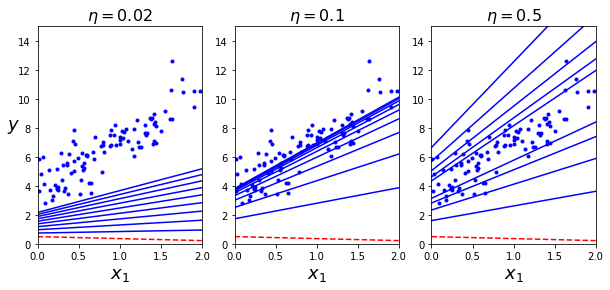

In [14]:
np.random.seed(42)
theta = np.random.randn(2,1)  # random initialization

plt.figure(figsize=(10,4))
plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(132); plot_gradient_descent(theta, eta=0.1, theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)

plt.show();

* Na esquerda, temos um learning rate muito baixo:
    * O algoritmo irá eventualmente atingir a solução, mas levará um longo tempo;
* No centro, temos um bom learning rate para essa tarefa:
    * Em poucas iterações o algoritmo convergiu;
* Na direita, temos um learning rate muito alto:
    * O Algoritmo acaba divergindo;

### Ajustando Parâmetros do Gradiente descendente

* Para escolher o learning rate você pode usar o gridsearch:
    * É importante limitar o número de iterações para o gridsearch eliminar modelos que levam muito tempo para convergir;
* Mas como definir o número máximo de iterações?
    * Uma solução simples é definir um valor muito alto e interromper o algoritmo quando o vetor gradiente atingir valores bem pequenos:
        * Isto é, quando a norma do vetor for menor que um número bem pequeno $\epsilon$ (chamado de tolerância)
        * Observe que nesse momento o algoritmo já está muito próximo de atingir o mínimo;

* Uma outra forma de analisar o learning rate é plotando a função de custo ao longo das iterações do gradiente descendente:

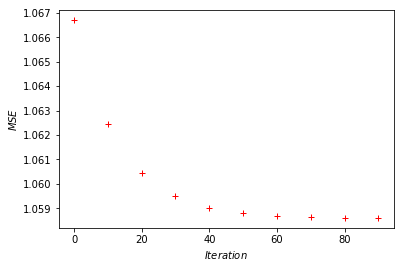

In [28]:
from sklearn.metrics import mean_squared_error
for iteration in range(100):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - 0.01 * gradients
    if iteration%10==0:
        y_pred = X_b.dot(theta)
        MSE = mean_squared_error(y, y_pred)
        plt.plot(iteration, MSE, "r+")
plt.xlabel("$Iteration$")
plt.ylabel("$MSE$")
plt.show();

## Gradiente Descendente Estocástico

* O maior problema do Batch Gradiente Descendente é que ele usa o base de treino inteira em cada iteração para computar os gradientes;
* O Gradiente Descendente Estocástico seleciona aleatoriamente apenas uma instância da base de treino em cada iteração e computa os gradientes baseado apenas nessa instância;
    * Isso torna o gradiente descendente estocástico muito mais rápido;
        * É possível treinar com bases de dados enormes, uma vez que apenas uma instância precisará estar na memória para cada iteração.
    * Por outro lado, esse algoritmo é muito menos regular que o Batch Gradiente Descendente
        * em vez de diminuir suavemente até atingir o mínimo, a função de custo vai saltar para cima e para baixo, diminuindo apenas em média.
    * Quando o algoritmo pára, os parâmetros são bons, mas não ótimos:

<img src="figures/gradient-stochastic.png"/>

* Note que quando a função de custo é bastante irregular, essa natureza aleatória do gradiente descendente estocástico pode ser útil para transpor (pular) locais mínimos;
    * Em outras palavras esse algoritmo tem mais chances de alcançar (ou chegar perto) o mínimo global do que o batch gradiente descendente;
* Assim, a aleatoriedade é boa para pular locais mínimos, mas ruim em relação ao algoritmo se estabelecer em um mínimo;
    * Uma solução para isso é reduzir o learning rate gradualmente;
    * A função que determina o learning rate em cada iteração é chamada de *learning schedule*;

O código abaixo implementa um Gradiente Descendente Estocástico usando um *learning schedule* bem simples
* o gráfico mostra as 20 primeiras hipóteses - observe o quão irregular elas são:

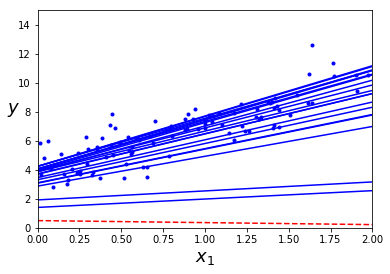

In [16]:
theta_path_sgd = []
m = len(X_b)
np.random.seed(42)

n_epochs = 50

t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)  # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i < 20:
            y_predict = X_new_b.dot(theta)
            style = "b-" if i > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

* Observe que enquanto o Batch Gradiente Descendente iterou 1000 vezes (usando a base de treino inteira em cada iteração);
* o Gradiente Descendente Estocástico iterou em 50 épocas com rounds de 100 (valor de m) e chegou a uma solução boa:

In [17]:
theta

array([[3.78672813],
       [3.3308738 ]])

In [18]:
theta_best

array([[3.76387713],
       [3.31160384]])

* Para aplicar Regressão Linear utilizando Gradiente Descendente Estocástico com o scikit-learn use a classe *SGDRegressor*.
* O código a seguir:
    * roda no máximo em 50 épocas (max_iter=50) ou até funçao de custo reduzir menos que 1e-3 a cada iteração (tol=1e-3);
    * o learning rate foi inicializado com 0.1 (eta0=0.1)
    * usa o *learning schedule* padrão (diferente do que foi apresentado anteriormente);
    * não utiliza regularização (penalty=None; será explicado em breve).

In [19]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=50, tol=1e-3, penalty=None, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel())

SGDRegressor(alpha=0.0001, average=False, early_stopping=False, epsilon=0.1,
       eta0=0.1, fit_intercept=True, l1_ratio=0.15,
       learning_rate='invscaling', loss='squared_loss', max_iter=50,
       n_iter=None, n_iter_no_change=5, penalty=None, power_t=0.25,
       random_state=42, shuffle=True, tol=0.001, validation_fraction=0.1,
       verbose=0, warm_start=False)

* Novamente, encontramos valores próximos aos do *theta_best*:

In [20]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.74329545]), array([3.33089734]))

In [21]:
theta_best

array([[3.76387713],
       [3.31160384]])

## Mini-batch Gradiente Descendente

* O Mini-batch Gradiente Descendente é um meio termo entre o Batch Gradiente Descendente e o Gradiente Descendente estocástico;
* Ao invés de usar a base de dados inteira para cada iteração, esse algoritmo usa apenas uma amostra dela (mini-batch);
* Assim, esse algoritmo tende a ficar mais próximo do mínimo do que o gradiente descendente estocástico;
* Por outro lado, ele é um mais suscetível a locais mínimos do que o gradiente descendente estocástico;

Veja abaixo a implementação do Mini-batch Gradiente Descendente:

In [22]:
theta_path_mgd = []

n_iterations = 50
minibatch_size = 20

np.random.seed(42)
theta = np.random.randn(2,1)  # inicialização aleatória

t0, t1 = 200, 1000
def learning_schedule(t):
    return t0 / (t + t1)

t = 0
for epoch in range(n_iterations):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, m, minibatch_size):
        t += 1
        xi = X_b_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

In [23]:
theta

array([[3.82391605],
       [3.34926331]])

In [24]:
theta_best

array([[3.76387713],
       [3.31160384]])

* A figura abaixo mostra os passos dos três algoritmos de otimização com gradiente descendentes vistos:

In [25]:
theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

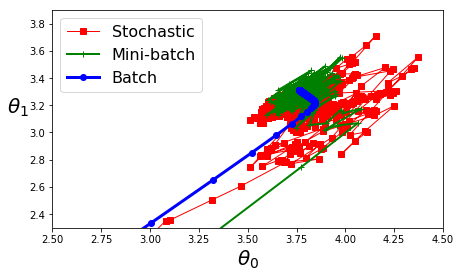

In [27]:
plt.figure(figsize=(7,4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1, label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2, label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3, label="Batch")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20, rotation=0)
plt.axis([2.5, 4.5, 2.3, 3.9])
plt.show()

# Regressão Polinomial

* Às vezes nossos dados são complexos e não são adaptáveis a um modelo linear;
* Nesses casos, podemos usar potências das nossas features como novas features e treinar um modelo linear (ex.: LinearRegression) com elas;

Vejamos um exemplo:

* Primeiramente vamos gerar dados não-lineares com base em uma equação quadrática mais algum ruído:

In [5]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

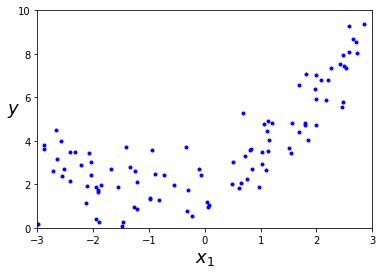

In [6]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

* Claramente uma função linear não irá se adaptar a esses dados;
* Iremos usar a classe PolynomialFeatures para efetuar uma transformação polinomial nos dados de treino;
    * Adicionaremos $X^2$ como uma nova feature:

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[-0.06808648]
[-0.06808648  0.00463577]


* Agora, *X_poly* possui o $X$ e $X^2$;
* Agora podemos usar uma simples regressão linear para treinar o modelo com esses dados extendidos:

In [8]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.05546116]), array([[0.97926971, 0.48158886]]))

* O modelo encontrou coeficientes próximos dos que nós criamos:
<br>
$h = 0.48x_1^2 + 0.98x_1 + 2.05$ (regressão polinomial)
<br>
$y = 0.5x_1^2 + 1.0x_1 + 2.0 + Gaussian noise$

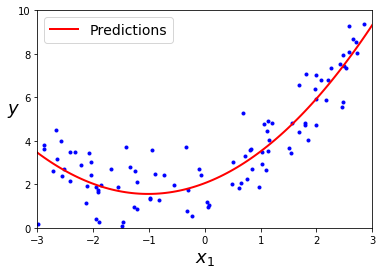

In [10]:
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

* Se usarmos uma regressão polinomial com potências ainda mais altas, o modelo provavelmente irá se adaptar ainda melhor aos dados de treino;
* O gráfico abaixo mostra um modelo linear (grau 1), quadrático (grau 2) e um modelo polinomial com grau 300.

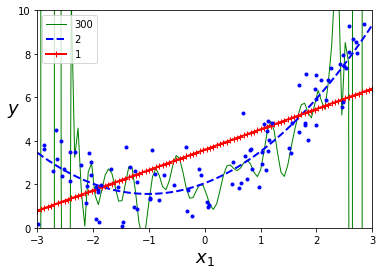

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

* Na regressão polinomial com grau 300 o que acontece é um *overfitting*, enquanto no modelo de grau 1 (linear) o que  acontece é um *underfitting*.
* O modelo que generaliza melhor é o que usa a função quadrática;
* Mas como verificar se o modelo está generalizando bem?
    * Observe que se o modelo apresenta bom desempenho no treino e baixo desempenho no teste, então temos um overfitting;
    * Se o modelo tem um desempenho ruim em ambos então temos um underfitting;
* Para verificar se o modelo generaliza bem podemos usar as curvas de aprendizagem (learning curves):
    * learning curves são gráficos do desempenho do modelo no conjunto de treinamento e no conjunto de validação em função do tamanho do conjunto de treinamento (ou da iteração de treinamento). 
    * Para gerar os gráficos, simplesmente treine o modelo várias vezes em subconjuntos de tamanhos diferentes do conjunto de treinamento. 
    * O código a seguir define uma função que plota as curvas de aprendizado de um modelo, dados alguns dados de treinamento:

In [12]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)

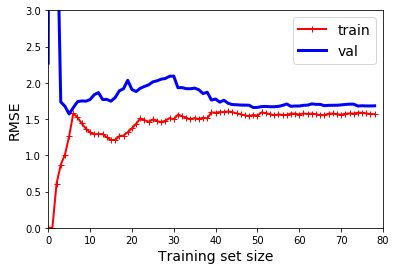

In [14]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

* Note que quando temos poucos dados de treino o modelo atinge um baixo RMSE no treino, mas um alto RMSE na validação.
* À medida que o modelo tem uma quantidade de dados de treino maior a performance no treino e validação se equilibra;
    * Nesse caso temos uma curva típica de um modelo com underfitting;
    * Ambas as curvas alcançaram um platô; 
        * eles estão próximos e bastante altos.
    * Em casos de underfitting não adianta adicionar mais exemplos de treinamento. 
        * Você precisa usar um modelo mais complexo ou obter melhores features.

* Agora, vamos ver as learning curves de um modelo polinomial de 10º grau nos mesmos dados:

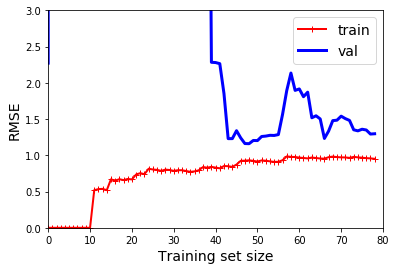

In [16]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])

plot_learning_curves(polynomial_regression, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

* Os erros nos dados de treinamento são muito menores do que no modelo de Regressão Linear;
* Há um gap entre as curvas. 
    * Isso significa que o modelo apresenta um desempenho significativamente melhor nos dados de treinamento do que nos dados de validação, 
    * Lembre que isso é a marca registrada de um modelo com overfitting. 
    * No entanto, se você usou um conjunto de treinamento muito maior, as duas curvas continuariam se aproximando
        * Uma maneira de melhorar um modelo com overfitting é fornecer mais dados de treinamento até que o erro de validação atinja o erro de treinamento.

# Modelos Lineares com Regularização

* Uma boa maneira de reduzir o overfitting é regularizar o modelo (ou seja, restringi-lo): 
    * quanto menos graus de liberdade ele tiver, mais difícil será para ele ter um overfitting. 
    * Por exemplo, uma maneira simples de regularizar um modelo polinomial é reduzir o número de graus polinomiais.
* Para um modelo linear, a regularização é tipicamente obtida restringindo os pesos do modelo.
* Veremos Ridge Regression, Lasso Regression e Elastic Net, que implementam três maneiras diferentes de restringir os pesos.

## Ridge Regression

Ridge Regression (também chamada de regularização de Tikhonov) é uma versão regularizada de Regressão Linear: 
<br>
um termo de regularização igual a $ \alpha \sum_{i=1}^{n} = θ_i^2$  é adicionado à função de custo.
* Isso força o algoritmo de aprendizado a não apenas ajustar os dados, mas também manter os pesos do modelo o menor possível.
* Observe que o termo de regularização só deve ser adicionado à função de custo durante o treinamento.
* O hiperparâmetro α controla o quanto você deseja regularizar o modelo.
    * Se α = 0, então a Regressão de Ridge é apenas Regressão Linear. 
    * Se α é muito grande, todos os pesos acabam muito próximos de zero e o resultado é uma linha reta passando pela média dos dados (observe que o somatório começa em 1 logo não há restrição para o $θ_0$).
* É importante padronizar/normalizar os dados (por exemplo, usando um StandardScaler) antes de executar O Ridge Regressor, pois ele é sensível à escala dos recursos de entrada. 
* Isso vale para a maioria dos modelos com regularização.

A Figura abaixo mostra vários modelos Ridge treinados em alguns dados lineares usando um valor α diferente.
    * o gráfico à esquerda mostra um modelo polinomial de grau 1
    * o gráfico à direita mostra um modelo polinomial de grau 10

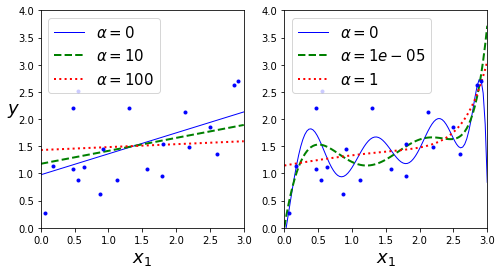

In [23]:
from sklearn.linear_model import Ridge

np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)

plt.show()

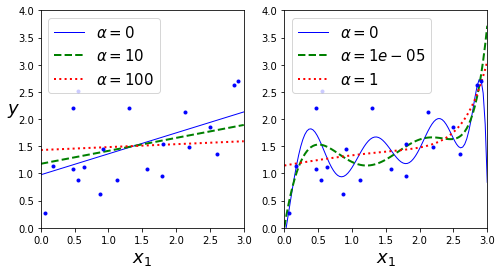

In [8]:
from sklearn.linear_model import Ridge

np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)

plt.show()

A equação normal também pode ser aplicada no Ridge Regression, conforme segue:

<font size=4>
$θ = (X^TX+αA)^{−1} X^T y$
</font>

* Para usar o Ridge Regression no scikit-learn:

In [9]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

* Podemos ainda usar o gradiente descendente estocástico regularização Ridge (penalty="l2"):

In [12]:
sgd_reg = SGDRegressor(max_iter=50, tol=-np.infty, penalty="l2", random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.49905184])

## Lasso Regression

* Least Absolute Shrinkage e Selection Operator Regression (chamado de  Lasso Regression) é outra forma de realizar regularização;
* Similar ao Ridge Regression, esse método adiciona a função custo um termo de regularização utilizado a norma ℓ1 (Lasso), ao invés da ℓ2 (Ridge);
* Veja abaixo a função custo usando Lasso:

<font size=3>
$J(θ) = MSE(θ) + α\sum_{i=1}^{n}|θ_i|$
</font>

* A Figura abaixo substitui os modelos Ridge por modelos Lasso e usa valores α menores:

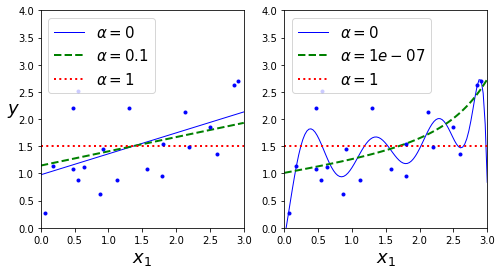

In [14]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 10**-7, 1), tol=1, random_state=42)

plt.show()

* Uma característica relevante do Lasso Regression é que ele tende a eliminar completamente os pesos das características menos importantes (isto é, defini-los para zero).
* Por exemplo a modelo cor verde à direita (α = 1e - 07) parece quadrático, mas é quase linear. 
    * todos os pesos para as features de polinômio de alto grau são iguais a zero;
    * Em outras palavras, o Lasso Regression executa automaticamente a seleção de atributos;

* Segue abaixo um exemplo de uso do Lasso com o scikit-learn:

In [15]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

## Elastic Net

* Elastic Net é um meio termo entre a Ridge e Lasso.
* O termo de regularização (r) é uma mistura simples dos termos de regularização de Ridge e Lasso:
* Pode-se controlar a taxa dessa mistura r. 
    * Quando r = 0, Elastic Net é equivalente a Ridge Regression
    * Quando r = 1, é equivalente a Lasso Regression.

<font size=3>
$ J(θ) = MSE(θ) + rα\sum_{i=1}^{n}|θ_i| + \frac{1−r}{2} α\sum_{i=1}^{n} θ_{i}^{2} $
</font>

* Então, quando você deve usar a Regressão Linear (ou seja, sem qualquer regularização, Ridge, Lasso ou Elastic Net)? 
    * Quase sempre é preferível ter pelo menos um pouco de regularização, então geralmente você deve evitar a Regressão Linear simples. 
    * Normalmente use-se o Ridge como padrão, mas se você suspeitar que apenas algumas features são realmente úteis, você deve preferir o Lasso ou o Elastic Net. 
    * Em geral, Elastic Net é preferível ao Lasso, já que o Lasso pode se comportar de forma errática quando o número de recursos for maior que o número de instâncias de treinamento ou quando vários recursos estiverem fortemente correlacionados.

* Abaixo um exemplo de uso do ElasticNet no scikit-learn:

In [16]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

## Early stopping

* Uma forma muito diferente de regularizar algoritmos de aprendizado interativos, como o gradiente descendente, é interromper o treinamento assim que o **erro de validação** atingir um mínimo.
* Essa técnica é chamada de *Early stopping*;
* É uma técnica de regularização tão simples e eficiente que Geoffrey Hinton chamou de “beautiful free lunch”.

* Abaixo uma implementação simples do Early stopping utilizando gradiente descendente estocástico:

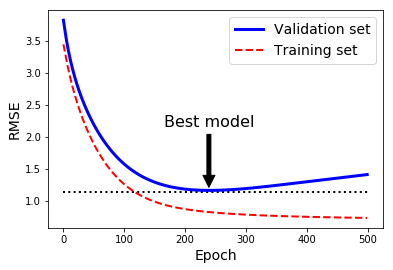

In [21]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X + 0.5 * X**2 + np.random.randn(m, 1)

X_train, X_val, y_train, y_val = train_test_split(X[:50], y[:50].ravel(), test_size=0.5, random_state=10)

poly_scaler = Pipeline([
        ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
        ("std_scaler", StandardScaler()),
    ])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter=1,
                       tol=-np.infty,
                       penalty=None,
                       eta0=0.0005,
                       warm_start=True,
                       learning_rate="constant",
                       random_state=42)

n_epochs = 500
train_errors, val_errors = [], []
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

best_epoch = np.argmin(val_errors)
best_val_rmse = np.sqrt(val_errors[best_epoch])

plt.annotate('Best model',
             xy=(best_epoch, best_val_rmse),
             xytext=(best_epoch, best_val_rmse + 1),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=16,
            )

best_val_rmse -= 0.03  # just to make the graph look better
plt.plot([0, n_epochs], [best_val_rmse, best_val_rmse], "k:", linewidth=2)
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation set")
plt.plot(np.sqrt(train_errors), "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.show()

# Regressão Logística

Regressão Logística é comumente usada para estimar a probabilidade de uma instância pertencer a uma determinada classe;
* Para derterminar a classe, usa-se um threshold:
    * Se a probabilidade é maior ou igual a 0.5, então a classe é positiva (1). Caso contrário, negativa (0);
* Da mesma forma que a regressão linear, o regressão logística procura pelo melhor valor para os coeficientes da features (vetor θ);
* Entretanto, a saída de uma regressão linear pode ter valores <0 e >1, o que não é desejável já que $y \in \{0,1\}$
* Assim, a saída da função de regressão é usada como entrada em uma função sigmoid (também conhecida como função logística):

<font size=3.4>
$\hat{p} = h_θ(x) = σ(θ^Tx)$
</font>

* A função sigmoid *σ* tem como saída valores $0 <= \hat{p} <= 1$:

<font size=4.5>
$σ(t) = \frac{1}{1 + e^{-t}}$
</font>

<img src="figures/sigmoid.png"/>

Uma vez que $\hat{p} = h_θ(x)$ é calculado, podemos calcular $\hat{y}$ facilmente:

<img src="figures/class.png"/>

* Observe que quando t < 0, então σ(t) < 0.5 e que t ≥ 0 quando σ(t) ≥ 0.5;
    * Em outras palavras, a regressão logistíca estima 1 quando $\hat{y} = θ^Tx$ é positivo e 0 quando $\hat{y} = θ^Tx$ é negativo.
    * Por exemplo, se $\hat{y} = 0.7$, então a probabilidade da instância ser positiva é de 70%;
* Lembre-se que:
<br>
<font size=3.4>
$P(\hat{y}=1|x:θ) + P(\hat{y}=0|x:θ) = 1$
</font>
* Logo:
<br>
<font size=3.4>
$P(\hat{y}=0|x:θ) = 1 - P(\hat{y}=1|x:θ)$
</font>


<h5>Nota</h5>

$P(\hat{y}=1|x:θ)$ -> lê-se: probabilidade de $\hat{y} = 1$, dado x parametrizado com θ

## Superfície de Decisão

Imagine que temos uma base de treino com duas classes, conforme imagem abaixo:

<img src="figures/linear_dec_bound.png"/>

* Temos que encontrar os melhores parâmetros $θ_0 .. θ_2$ para o nosso modelo:

<font size=3.4>
$h_θ(x) = σ(θ_0 + θ_1x_1 + θ_2x_2)$
</font>

* Lembrando que h_θ(x) = 1, se

<font size=3.4>
$θ_0 + θ_1x_1 + θ_2x_2 \geq 0$
</font>

e $h_θ(x) = 0$, do contrário;
* Para $θ^T = [-3, 1, 1]$, temos o seguinte modelo:

<font size=3.4>
$-3 + x_1 + x_2 \geq 0$
</font>

* Logo:

<font size=3.4>
$x_1 + x_2 \geq 3$
</font>

* Observe que para $x_1 + x_2 = 3$, temos $h_θ(0) = 0.5$;
* Essa equação da reta é nossa superfície de decisão, pois:
    * se $x_1 + x_2 \geq 3$, então $\hat{y} = 1$
    * se $x_1 + x_2 < 3$, então $\hat{y} = 0$
    
<img src="figures/dec_bound_2.png"/>

### Superfícies de decisão não-lineares

Por outra lado, às vezes precisamos de superfícies de decisão não lineares, como por exemplo a mostrada abaixo:

<img src="figures/dec_bound_non_linear.png"/>

* Nesses casos, podemos usar a seguinte regressão polinomial:

<font size=3.4>
$h_θ(x) = σ(θ_0 + θ_1x_1 + θ_2x_2 + θ_3x_1^2 + θ_4x_2^2)$
</font>

* Para $θ^T = [-1, 0, 0, 1, 1]$, temos o seguinte modelo:

<font size=3.4>
$h_θ(x) = σ(-1 + x_1^2 + x_2^2)$
</font>

* Nesse modelo, quando $x_1^2 + x_2^2 = 1$, temos $h_θ(x) = 0.5$
    * Essa será nossa superfície de decisão, isto é, uma circunferência de raio=1:

<img src="figures/dec_bound_non_linear_2.png"/>

## Como treinar o modelo

* A função sigmóide retorna valores entre [0-1];
* Dito isso, devemos ajustar os parâmetros com base nas estimativas do modelo ($\hat{p}$) e nas classes (y).
    * Assim, se uma instância tem rótulo 1 (y=1), é desejável que a função sigmóide retorne um valor próximo de 1 (ou ao menos $\hat{p}>0.5$). 
    * Em outras palavras, queremos que:

    $|(P(\hat{y}=1|x:θ) - y)| \rightarrow 0$, sendo y=1
        
    $|(P(\hat{y}=0|x:θ) - y)| \rightarrow 0$, sendo y=0

* Podemos primeiramente pensar em uma função de custo (J(θ)) similar a da regressão linear (com algumas adaptações):

<font size=3.4>
$J(θ) = \frac{1}{m}\sum_{i=1}^{m} (h_θ(x^{(i)}) − y^{(i)})^2$
</font>

O problema é que a função custo J(θ), usando a função
<font size=3.4>
$h_θ(x^{(i)}) = \frac{1}{1 + e^{-θ^{T}x}}$
</font>
, não é convexa!
* Assim, usaremos outra função de custo (J(θ) - convexa) que captura a intuição de que:
    * J(θ) = 0, se y = 1 e $h_θ(x) = 1$
        * Mas se $h_θ(x) \rightarrow 0$, sendo y=1
        * Então $J(θ)\rightarrow \infty$
    * J(θ) = 0, se y = 0 e $h_θ(x) = 0$
        * Mas se $h_θ(x) \rightarrow 1$, sendo y=0,
        * Então $J(θ)\rightarrow \infty$

* A funçao *c* que atende os nossos requisitos é a seguinte:

<img src="figures/cost_func_log_reg.png" />

* Veja no gráfico abaixo que -$-log(\hat{p})$ (para y=1) cresce rapidamente quando $\hat{p}$ se aproxima de 0.
    * Assim, o erro (função de custo) é alto se o modelo estimar uma probabilidade próxima de 0 quando y=1.
* O erro também será alto se estimarmos uma probabilidade próxima de 1 sendo que a classe y=0;

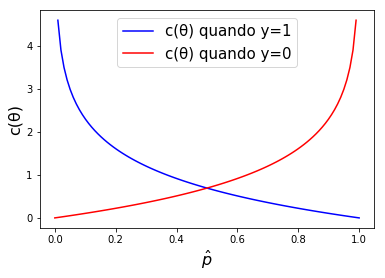

In [11]:
x = np.linspace(0, 1, 100)
y1 = -np.log(x[1:])
y2 = -np.log(1-x[:-1])

plt.plot(x[1:], y1, '-b', label='c(θ) quando y=1')
plt.plot(x[:-1], y2, '-r', label='c(θ) quando y=0')
plt.xlabel(r"$\hat{p}$", fontsize=16)
plt.ylabel('c(θ)', fontsize=16)
plt.legend(fontsize=15);

* Destaca-se que a função c(θ) calcula o erro de uma instância.
* Assim, a função de custo (J(θ)) é apenas a média aritmética dos custos de todas as instâncias da base de treino, conforme segue:

<font size=3.4>
$J(θ) = −\frac{1}{m} \sum_{i=1}^{m}[y^{(i)}log(\hat{p}^{i}) + (1 - y^{(i)})log(1 - \hat{p}^{i})]$
</font>

* A fução de custo acima é chamada de **log loss**;
* Note que, conforme especificado na função de custo c(θ):
    * se y=0, então a primeira parte ($y^{(i)}log(\hat{p}^{i})$) será 0.
    * Do contrário, y=1, então a segunda parte ($(1 - y^{(i)})log(1 - \hat{p}^{i})$) será 0
* A notícia ruim é que não existe uma fórmula fechada (como a equação normal) para computar diretamente os valores de θ;
* Mas a notícia boa é que essa função de custo é convexa, assim é garantido que o gradiente descendente (ou outr algoritmo de otimização) encontrará o mínimo global (com um número de iterações e um learning rate adequado);
* As derivadas parciais dessa função em relação a um parâmetro $θ_j$ é:

<font size=3.4>
$\frac{∂}{∂θ_j}J(θ) = \frac{1}{m} \sum_{i=1}^{m}(σ(θ^Tx^{(i)}) − y^{(i)})x_j^{(i)}$
</font>

* Na equação acima, para cada instância, computa-se e erro de predição e multiplica-se pelo valor da j-ésima feature. 
* Depois disso calcula-se a média aritmética dos erros de predição para todas as instâncias;
* Uma vez que você tem o vetor gradiente contendo tadas as derivadas parciais, basta usá-las no Batch Gradiente descendente;

<h4>Nota:</h4>

* Caso você deseje usar o gradiente descendente estocástico, basta usar apenas uma instância ao invés de todas;
* Caso queira usar o Mini Batch gradiente descendente, então use uma amostra dos dados de treino;
* Finalmente, assim como na regressão linear, os modelos de Regressão Logística podem ser regularizados usando penalidades ℓ1 ou ℓ2. 
    * O Scitkit-Learn usa por padrão a penalidade ℓ2;
    * No scikit-learn o parâmetro para controlar a quantidade de regularização é o C (mas ao inverso).
        * Quanto maior o valor de C, menos regularizado será o modelo de regressão logística;

# Softmax Regression

* Um modelo de regressão logística pode ser generalizado para suportar tarefas de classificação multiclasse;
* Uma forma é usar os métodos já explanados OneVersulAll e OneVersusOne
    * Nota: entre  OneVersulAll e OneVersusOne, para regressão logística OneVersulAll é uma opção mais utilizada;
* Entretanto, podemos fazer a regressão logística suportar tarefas de classificação multiclasse diretamente utilizando a Regressão Softmax (ou regressão logística multinomial);
* Dada uma instância x, a Regressão Softmax calcula um score $s_k(x)$ para cada classe k;
* Após isso, estima-se a probabilidade de cada classe usando a função softmax nos scores;
* A equação para calcular os scores é a mesma da regressão linear:

<font size=3.4>
$ s_k(x) =  θ_{k}^{T}x$
</font>

* Observe que para cada classe existirá uma vetor de parâmetros $θ^{(k)}$;
    * Esses parâmetros são tipicamente armazenados em uma *matriz de parâmetros* θ;
* Uma vez computado o score de uma instância x para cada classe, podemos calcular a probabilidade $\hat{p}_k$ da instância x pertencer a classe k usando o score de x como entrada na função softmax;
    * A função softmax computa o exponencial de cada score e os normaliza (dividindo pela soma de todos os exponenciais);
    * Os exponenciais são também chamados de *logits*;
    * Veja abaixo a equação:

<font size=5>
$ \hat{p}_k = σ(s(x))_k = \frac{e^{(s_k(x))}}{\sum_{j = 1}^{k} e^{(s_j(x))}} $
</font>

Onde,
* K é o númere de classes;
* s(x) é o vetor contendo os scores x para cada classe;
* $σ(s(x))_k$ é a probabilidade da instância x pertencer a classe k, dadas os scores de cada classe para a instância x;

* Veja abaixo um exemplo de uso da função softmax com scores fictícios:

In [10]:
def softmax(v):
    return np.exp(v)/np.sum(np.exp(v))

scores = [4.41,  1.47,  0.42,  1.07, -1.61]
x = np.array(scores)
probs = softmax(x)
probs

array([0.9015246 , 0.04765976, 0.01667795, 0.03194729, 0.00219041])

* Note que para realizar a classificão, a Regressão Softmax estima a classe com mair probabilidade:

<img src="figures/softmax_pred.png"/>

O argmax retorna o índice da classe com maior probabilidade;

## Como treinar o modelo

* Já sabemos como realizar a predição, agora vamos aprender a treinar a Regressão Softmax;
* O Objetivo deste modelo é estimar a maior probabilidade para a classe verdadeira (y_true);
    * Consequentemente, uma probabilidade baixa para as demais classes;
* Minimizar a função de custo J(θ) faz com que isso aconteça (em cenários propícios para tal);
* Essa função de custo é chamada de **cross entropy**

<font size=5>
$ J(\theta) = -\frac{1}{m} \sum_{i = 1}^{m} \sum_{k = 1}^{K} y_k^{(i)}log(\hat{p}_k^{(i)}) $
</font>

* $y_k^{(i)}$ é igual a 1 se a classe da i-ésima instância for k. Do contrário ela será 0;
* Nota: se K=2, então essa função é equivalente a função de custo da Regressão Logística (log loss);

O vetor gradiente dessa função de custo em relação ao vetor de parâmetros $θ_k$ é dado abaixo:

<img src="figures/gradient_softmax.png"/>

* Abaixo vamos aplicar uma Regressão Softmax usando o scikit-learn;
* Por padrão o scikit-learn usa o método OneVersusAll para tarefas multiclasse;
* Porém, podemos especificar o parâmetro  multi_class="multinomial" para usar o softmax;
    * Podemos definir também o solver="lbfgs" (veja a documentação do sklearn para mais detalhes)
* Por padrão é aplicada a regularização $ℓ_2$, a qual pode ser controlada pelo parâmetro $C$:

In [13]:
from sklearn.datasets import load_iris

iris = load_iris()

In [16]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10, random_state=42)
softmax_reg.fit(X, y)

LogisticRegression(C=10, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='multinomial',
          n_jobs=None, penalty='l2', random_state=42, solver='lbfgs',
          tol=0.0001, verbose=0, warm_start=False)

* A próxima vez que você avistar uma iris com 5 por 2 cm de petal, o modelo que treinamos irá responder que existe 94.2% de ser uma Iris-Virginica (classe 2) e 5.8% de chance de ser uma Iris-versicolor.

In [25]:
print(softmax_reg.predict([[5,2]]))
print(softmax_reg.predict_proba([[5,2]]).round(3))

[2]
[[0.    0.057 0.943]]


### Superfície de Decisão da Regressão Softmax

* O gráfico abaixo mostra as superfícies de decisão resultantes da Regressão Softmax, representados pelas cores de fundo. 
* Observe que os limites de decisão entre duas classes são lineares. 
* A figura também mostra as probabilidades para a classe Iris-Versicolor, representada pelas linhas curvas (por exemplo, a linha marcada com 0,450 representa o limite de probabilidade de 45%).

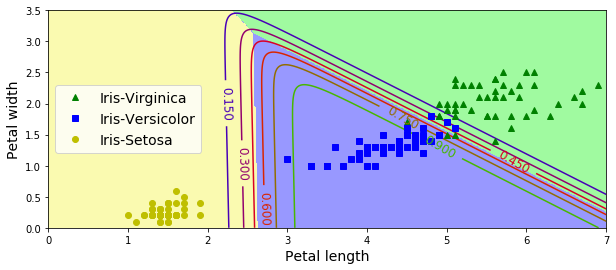

In [18]:
x0, x1 = np.meshgrid(
        np.linspace(0, 8, 500).reshape(-1, 1),
        np.linspace(0, 3.5, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]


y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==2, 0], X[y==2, 1], "g^", label="Iris-Virginica")
plt.plot(X[y==1, 0], X[y==1, 1], "bs", label="Iris-Versicolor")
plt.plot(X[y==0, 0], X[y==0, 1], "yo", label="Iris-Setosa")

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap=plt.cm.brg)
plt.clabel(contour, inline=1, fontsize=12)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 7, 0, 3.5])
plt.show()

## Principais referências para esta aula

* Géron, Aurélien. Hands-on machine learning with Scikit-Learn and TensorFlow: concepts, tools, and techniques to build intelligent systems. " O'Reilly Media, Inc.", 2017.
* [Scikit-Learn - Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
* [Scikit-learn - Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)